In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D27',
    'axes.edgecolor':    '#2E3250',
    'axes.labelcolor':   '#E0E0E0',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#FFFFFF',
    'xtick.color':       '#B0B0B0',
    'ytick.color':       '#B0B0B0',
    'text.color':        '#E0E0E0',
    'grid.color':        '#2E3250',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        150,
})

COLORS = {
    'primary':   '#4F8EF7',
    'secondary': '#F7C948',
    'accent':    '#F75A5A',
    'green':     '#4CAF82',
    'purple':    '#9B59F7',
    'text':      '#FFFFFF',
    'subtext':   '#B0B0B0',
}

CHARTS_DIR = '../outputs/charts/'

def save_chart(filename):
    plt.savefig(f"{CHARTS_DIR}{filename}",
                bbox_inches='tight',
                facecolor=plt.rcParams['figure.facecolor'],
                dpi=150)
    plt.show()
    print(f"✅ Saved: {CHARTS_DIR}{filename}")

df_tech   = pd.read_csv('../data/processed/tech_jobs_cleaned.csv')
df_skills = pd.read_csv('../data/processed/skills_exploded.csv')
df_salary = df_tech[df_tech['salary_lpa'] > 0].copy()

print(f"✅ Setup complete | df_tech: {df_tech.shape}")

✅ Setup complete | df_tech: (32438, 28)


In [2]:
# ── Analysis 8.1: Hiring Recency Distribution ─────────────────

# First, let's see what values actually exist
print("Unique jobUploaded values:")
print(df_tech['jobUploaded'].value_counts().head(20))

Unique jobUploaded values:
jobUploaded
4 Days Ago       5712
10 Days Ago      5197
8 Days Ago       4431
7 Days Ago       3754
3 Days Ago       3562
9 Days Ago       2852
2 Days Ago       2523
Few Hours Ago    1485
Just Now         1262
Today             660
6 Days Ago        521
1 Day Ago         322
5 Days Ago        157
Name: count, dtype: int64


In [10]:
# ── Analysis 8.1: Hiring Velocity Over the Scrape Window ──────

# Map text values to numeric days ago
days_map = {
    'Just Now'     : 0,
    'Few Hours Ago': 0,
    'Today'        : 0,
    '1 Day Ago'    : 1,
    '2 Days Ago'   : 2,
    '3 Days Ago'   : 3,
    '4 Days Ago'   : 4,
    '5 Days Ago'   : 5,
    '6 Days Ago'   : 6,
    '7 Days Ago'   : 7,
    '8 Days Ago'   : 8,
    '9 Days Ago'   : 9,
    '10 Days Ago'  : 10,
}

df_tech['days_ago'] = df_tech['jobUploaded'].map(days_map)

# Daily posting counts
daily_volume = (df_tech.groupby('days_ago')
                .size()
                .reset_index(name='postings')
                .sort_values('days_ago'))

# Daily fresher-eligible counts
daily_fresher = (df_tech[df_tech['fresher_eligible']]
                 .groupby('days_ago')
                 .size()
                 .reset_index(name='fresher_postings'))

daily = daily_volume.merge(daily_fresher, on='days_ago', how='left')
daily['fresher_postings'] = daily['fresher_postings'].fillna(0).astype(int)
daily['non_fresher'] = daily['postings'] - daily['fresher_postings']
daily['fresher_pct'] = (daily['fresher_postings'] / daily['postings'] * 100).round(1)

# Map days_ago to readable labels
label_map = {
    0: 'Today/\nJust Now',
    1: 'Day 1', 2: 'Day 2', 3: 'Day 3',
    4: 'Day 4', 5: 'Day 5', 6: 'Day 6',
    7: 'Day 7', 8: 'Day 8', 9: 'Day 9',
    10: 'Day 10'
}
daily['label'] = daily['days_ago'].map(label_map)

print("Daily posting distribution:")
print(daily[['label', 'postings', 'fresher_postings', 'fresher_pct']].to_string(index=False))

Daily posting distribution:
           label  postings  fresher_postings  fresher_pct
Today/\nJust Now      3407               794         23.3
           Day 1       322                96         29.8
           Day 2      2523               581         23.0
           Day 3      3562               777         21.8
           Day 4      5712              1026         18.0
           Day 5       157                41         26.1
           Day 6       521               158         30.3
           Day 7      3754               669         17.8
           Day 8      4431               900         20.3
           Day 9      2852               626         21.9
          Day 10      5197               888         17.1


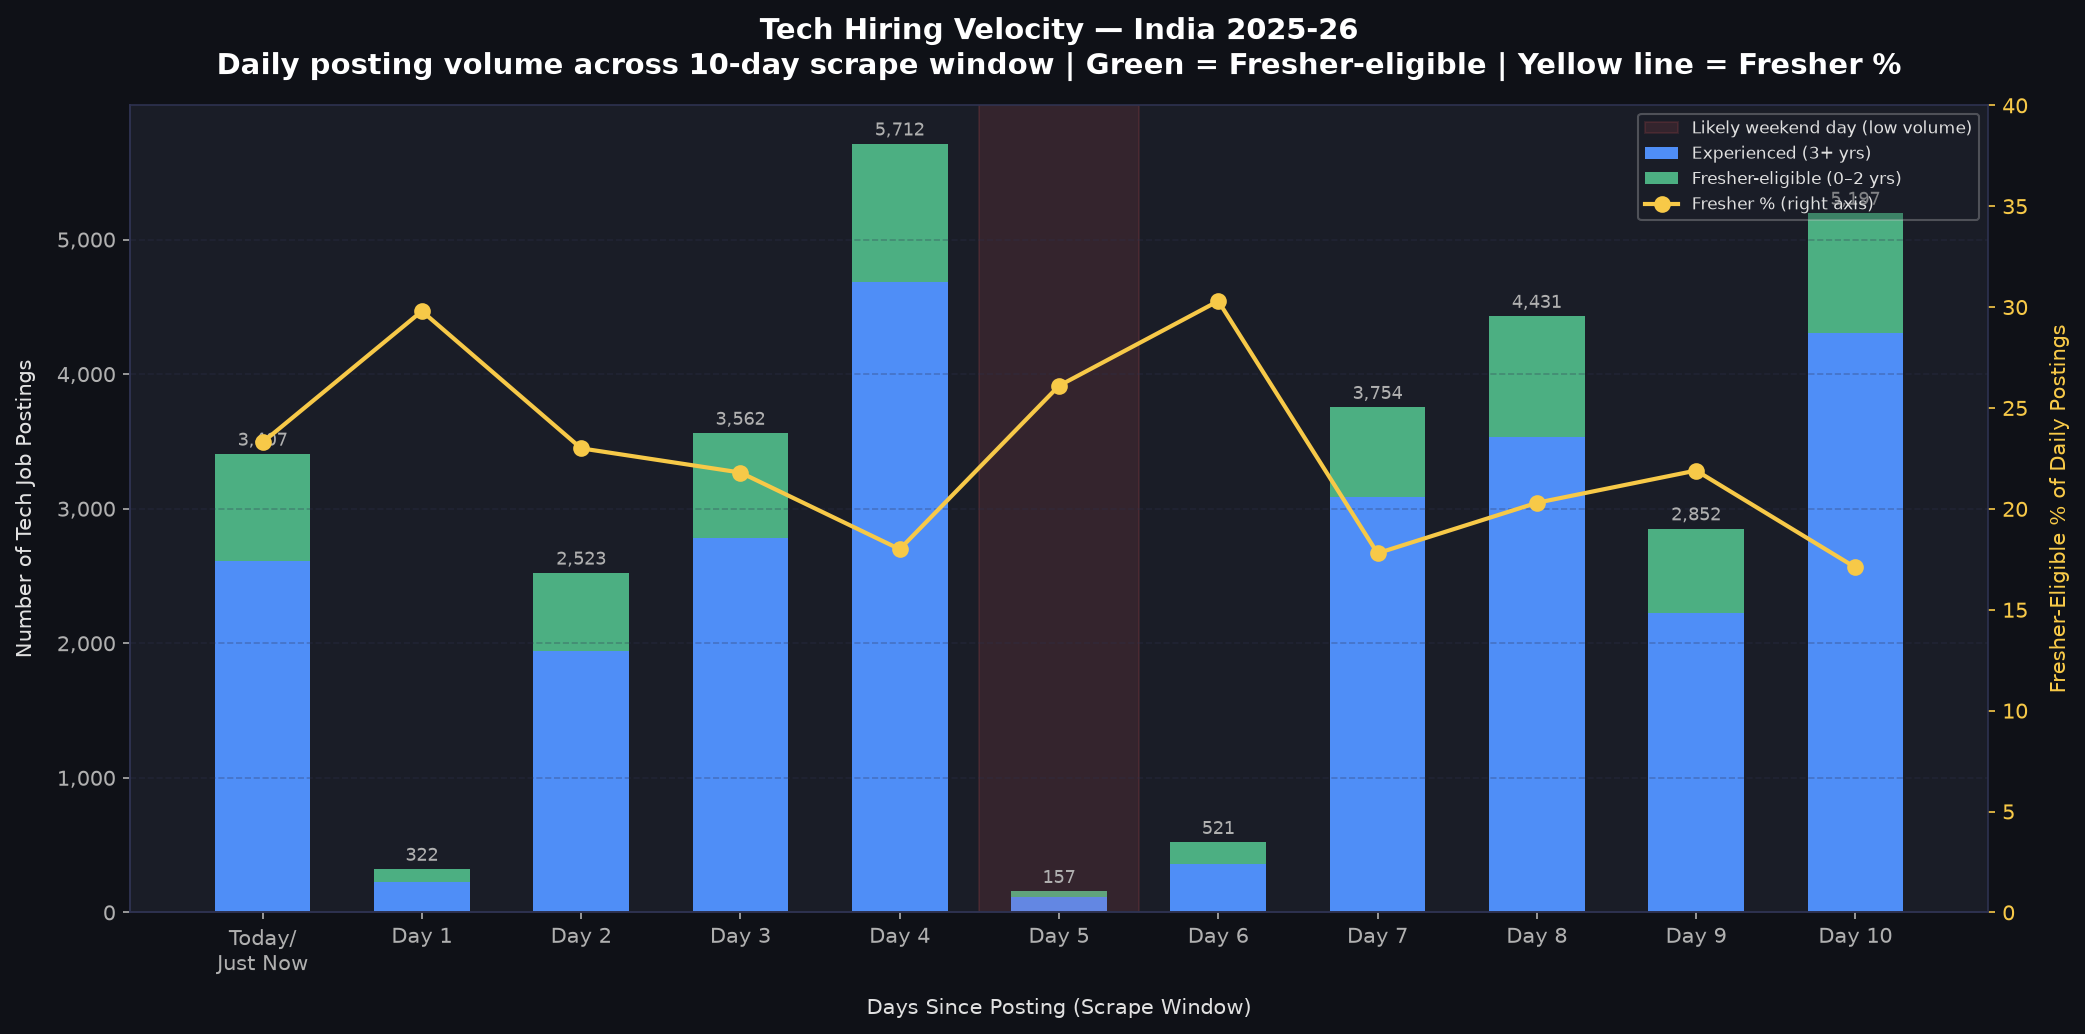

✅ Saved: ../outputs/charts/G0_hiring_velocity.png

Hiring velocity chart saved.


In [11]:
# ── Chart: Hiring Velocity with Fresher Overlay ───────────────
fig, ax1 = plt.subplots(figsize=(14, 7))

# Stacked bars: fresher vs non-fresher
bars1 = ax1.bar(daily['label'],
                daily['non_fresher'],
                color=COLORS['primary'],
                edgecolor='none',
                width=0.6,
                label='Experienced (3+ yrs)')

bars2 = ax1.bar(daily['label'],
                daily['fresher_postings'],
                bottom=daily['non_fresher'],
                color=COLORS['green'],
                edgecolor='none',
                width=0.6,
                label='Fresher-eligible (0–2 yrs)')

# Total labels on top of each bar
for bar, row in zip(bars1, daily.itertuples()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             row.postings + 30,
             f'{row.postings:,}',
             ha='center', va='bottom',
             fontsize=8.5, color=COLORS['subtext'])

# Fresher % line on secondary axis
ax2 = ax1.twinx()
ax2.plot(daily['label'],
         daily['fresher_pct'],
         color=COLORS['secondary'],
         linewidth=2,
         marker='o',
         markersize=7,
         label='Fresher % (right axis)',
         zorder=5)

ax2.set_ylabel('Fresher-Eligible % of Daily Postings',
               color=COLORS['secondary'], labelpad=10)
ax2.tick_params(axis='y', colors=COLORS['secondary'])
ax2.set_ylim(0, 40)

# Highlight Day 5 as likely weekend
ax1.axvspan(4.5, 5.5, alpha=0.12, color=COLORS['accent'],
            label='Likely weekend day (low volume)')

ax1.set_xlabel('Days Since Posting (Scrape Window)', labelpad=10)
ax1.set_ylabel('Number of Tech Job Postings', labelpad=10)
ax1.set_title('Tech Hiring Velocity — India 2025-26\n'
              'Daily posting volume across 10-day scrape window '
              '| Green = Fresher-eligible | Yellow line = Fresher %',
              pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=8, framealpha=0.3)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_chart('G0_hiring_velocity.png')
print("\nHiring velocity chart saved.")

In [6]:
# ── Analysis 8.2: Skill Co-occurrence Clusters ───────────────
# Which skills naturally appear together? 
# This reveals the "skill ecosystem" structure of India's tech market

# Top 15 skills to analyze
top15_skills = (df_skills['skill']
                .value_counts()
                .head(15)
                .index.tolist())

# Build co-occurrence matrix
# For each pair of skills, count how many jobs mention both
skill_jobs = {}
for skill in top15_skills:
    skill_jobs[skill] = set(df_skills[df_skills['skill'] == skill]['jobId'].values)

# Build matrix
cooc_matrix = pd.DataFrame(index=top15_skills, columns=top15_skills, dtype=float)

for s1 in top15_skills:
    for s2 in top15_skills:
        if s1 == s2:
            cooc_matrix.loc[s1, s2] = 1.0
        else:
            intersection = len(skill_jobs[s1] & skill_jobs[s2])
            union = len(skill_jobs[s1] | skill_jobs[s2])
            # Jaccard similarity: overlap / total unique jobs mentioning either
            cooc_matrix.loc[s1, s2] = intersection / union if union > 0 else 0

print("Co-occurrence matrix computed")
print(f"Shape: {cooc_matrix.shape}")
print(f"\nStrongest skill pairs (Jaccard similarity):")
pairs = []
for i, s1 in enumerate(top15_skills):
    for j, s2 in enumerate(top15_skills):
        if i < j:
            pairs.append((s1, s2, cooc_matrix.loc[s1, s2]))
pairs_df = pd.DataFrame(pairs, columns=['skill1', 'skill2', 'jaccard'])
print(pairs_df.nlargest(10, 'jaccard').to_string(index=False))

Co-occurrence matrix computed
Shape: (15, 15)

Strongest skill pairs (Jaccard similarity):
       skill1        skill2  jaccard
Microservices   Spring Boot 0.405341
         Java   Spring Boot 0.312042
         Java Microservices 0.243269
          CSS    JavaScript 0.200000
          CSS            C# 0.180788
          CSS      REST API 0.166043
       Python           SQL 0.135889
           C#           SAP 0.128027
         Java           CSS 0.111729
         Java      REST API 0.109247


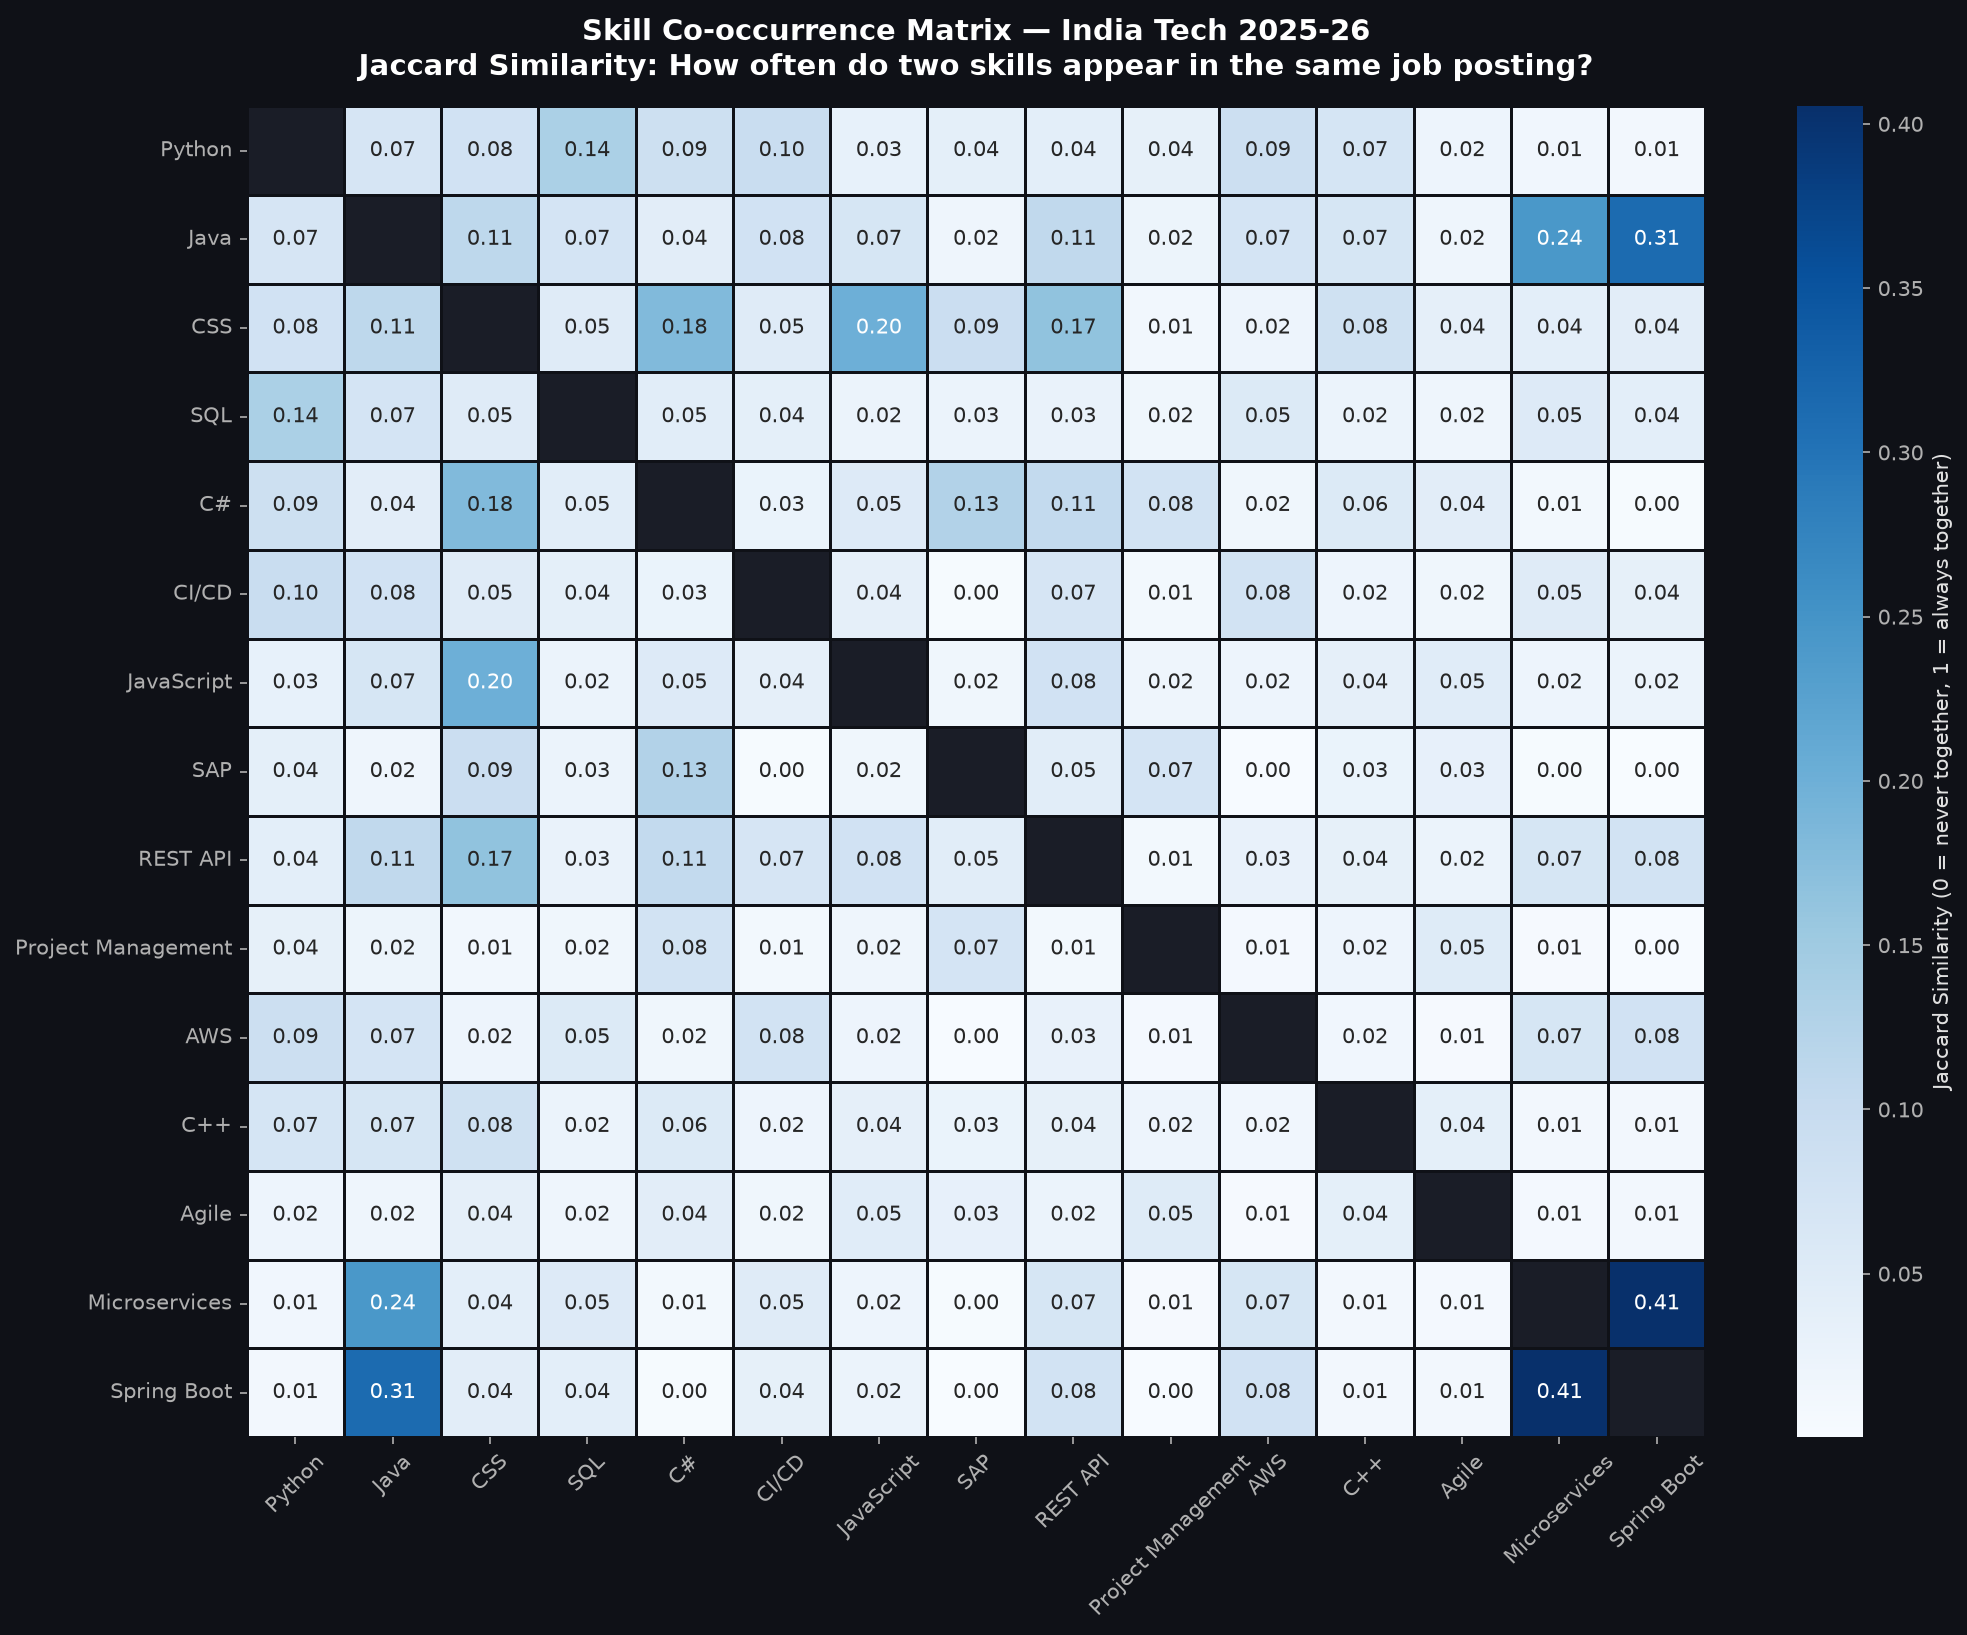

✅ Saved: ../outputs/charts/G1_skill_cooccurrence_matrix.png


In [7]:
# Visualize as heatmap
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.eye(len(top15_skills), dtype=bool)

sns.heatmap(cooc_matrix.astype(float),
            annot=True,
            fmt='.2f',
            cmap='Blues',
            mask=mask,
            linewidths=0.5,
            linecolor='#0F1117',
            ax=ax,
            cbar_kws={'label': 'Jaccard Similarity (0 = never together, 1 = always together)'})

ax.set_title('Skill Co-occurrence Matrix — India Tech 2025-26\n'
             'Jaccard Similarity: How often do two skills appear in the same job posting?',
             pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_chart('G1_skill_cooccurrence_matrix.png')

In [8]:
# ── Analysis 8.3: Which roles are best entry points? ─────────
# Map: Entry role → Salary at entry → Salary ceiling → 
#      Fresher accessibility → Recommended next role

career_data = []

for role in df_tech['role_category'].unique():
    role_df     = df_tech[df_tech['role_category'] == role]
    role_salary = df_salary[df_salary['role_category'] == role]
    
    total       = len(role_df)
    if total < 50:
        continue
    
    fresher_pct = (role_df['fresher_eligible'].sum() / total * 100)
    fresher_abs = role_df['fresher_eligible'].sum()
    
    # Fresher salary (0-2 yrs)
    fresher_sal = role_salary[role_salary['minimumExperience'] <= 2]['salary_lpa']
    
    # Senior salary (5+ yrs)
    senior_sal  = role_salary[role_salary['minimumExperience'] >= 5]['salary_lpa']
    
    career_data.append({
        'role'              : role,
        'total_postings'    : total,
        'fresher_pct'       : round(fresher_pct, 1),
        'fresher_abs'       : int(fresher_abs),
        'fresher_median_lpa': round(fresher_sal.median(), 2) if len(fresher_sal) >= 5 else None,
        'senior_median_lpa' : round(senior_sal.median(), 2) if len(senior_sal) >= 5 else None,
    })

career_df = pd.DataFrame(career_data)
career_df['salary_growth_x'] = (career_df['senior_median_lpa'] /
                                  career_df['fresher_median_lpa']).round(1)

career_df = career_df.dropna()
career_df = career_df.sort_values('fresher_pct', ascending=False)

print("CAREER PATH MAP — Role Analysis:")
print(career_df[['role', 'fresher_pct', 'fresher_abs',
                  'fresher_median_lpa', 'senior_median_lpa',
                  'salary_growth_x']].to_string(index=False))

CAREER PATH MAP — Role Analysis:
                      role  fresher_pct  fresher_abs  fresher_median_lpa  senior_median_lpa  salary_growth_x
     IT Support / Sysadmin         45.9          385                3.00               7.50              2.5
          Mobile Developer         33.9          119                3.90              12.00              3.1
              Data Analyst         26.3          100                5.00              17.50              3.5
        QA / Test Engineer         25.5          518                3.50              15.00              4.3
        Frontend Developer         23.2          115                5.20              19.00              3.7
         Software Engineer         22.5         3747                3.38              13.50              4.0
         Backend Developer         21.5          120                2.00              19.60              9.8
                Other Tech         21.2          363                3.75              17.00    

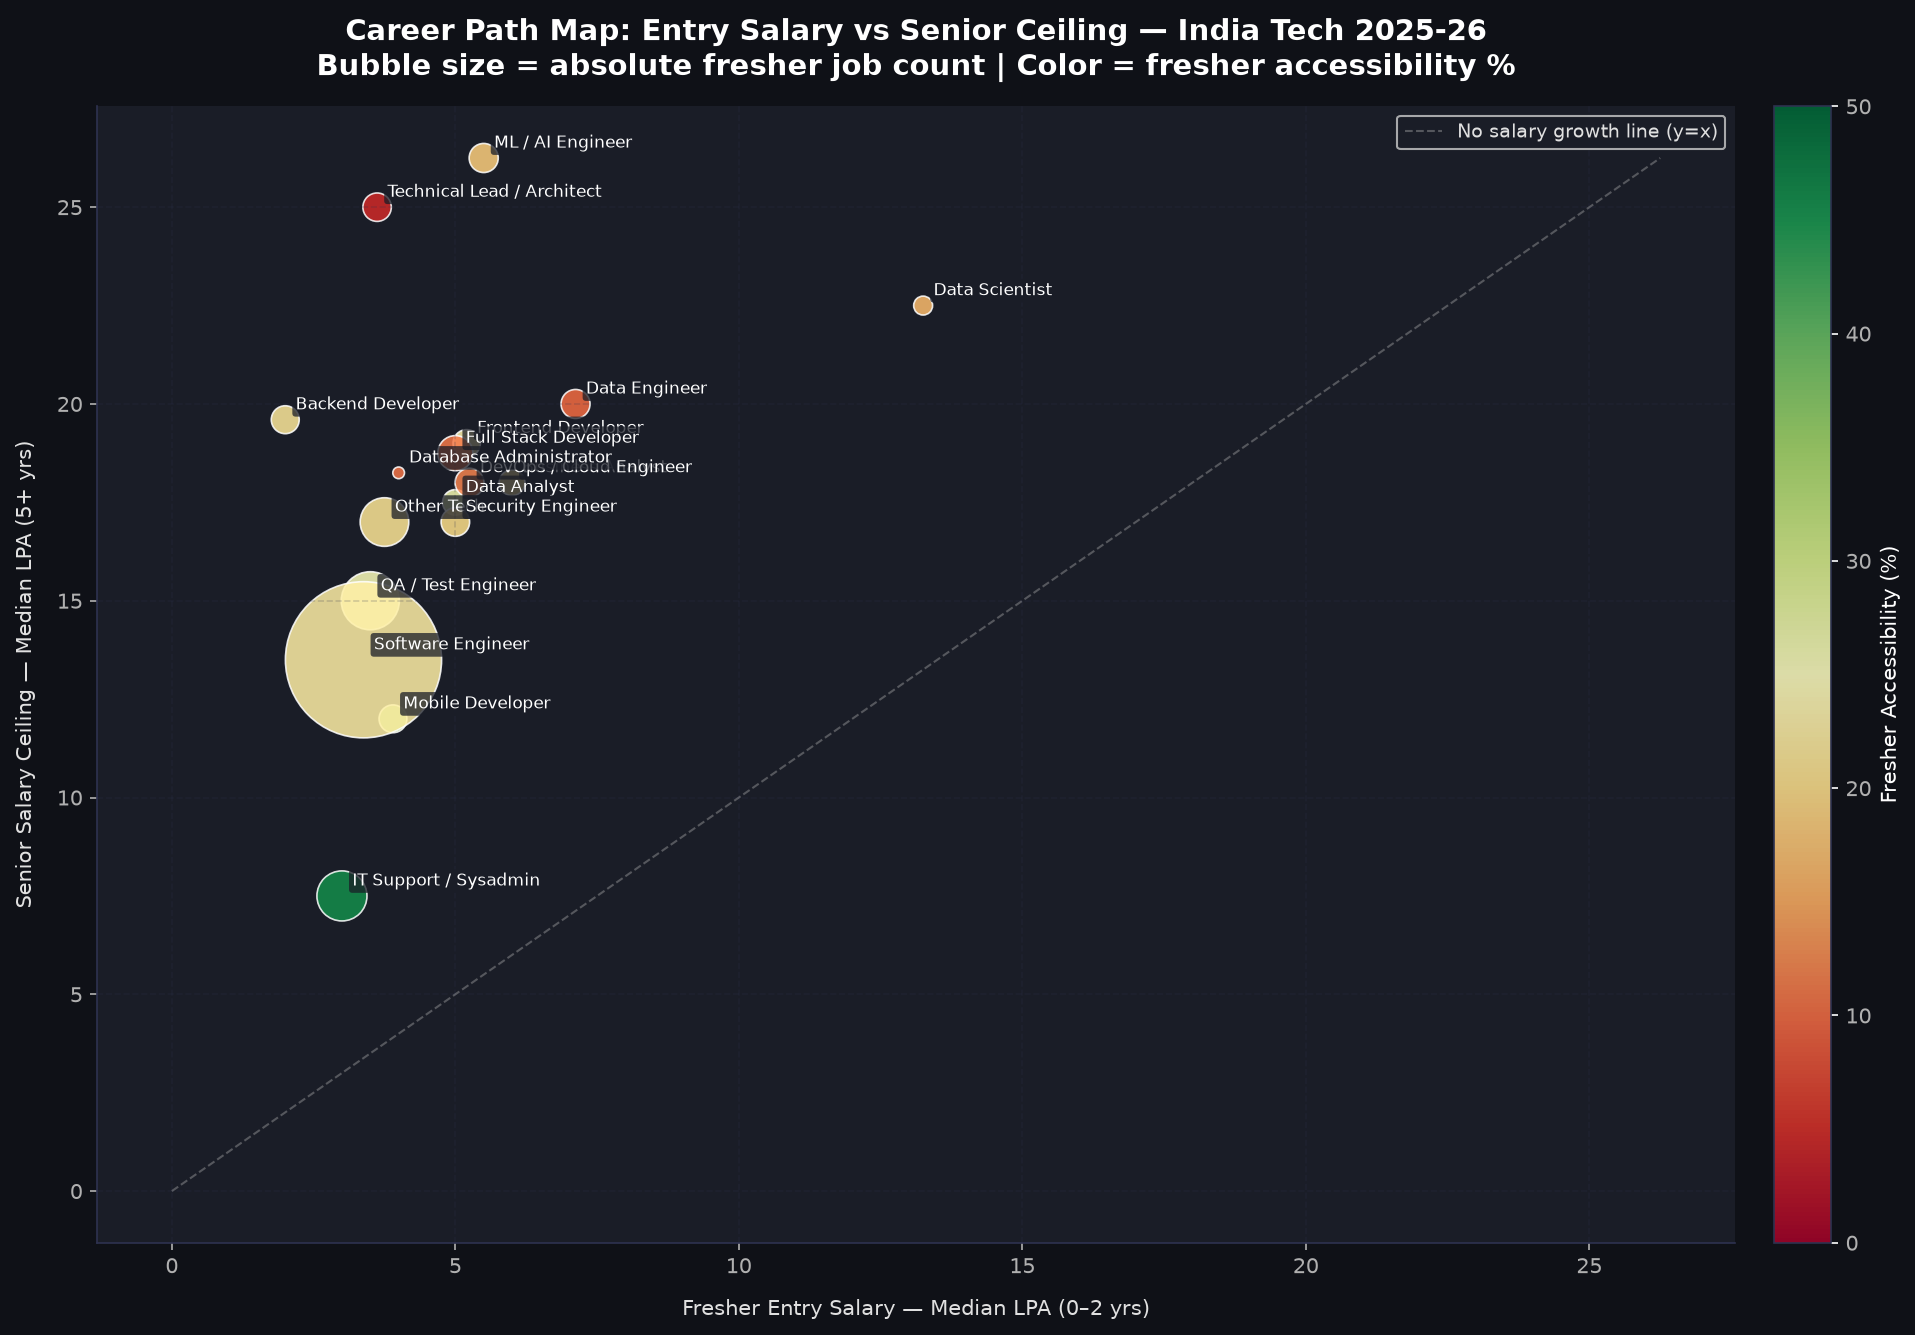

✅ Saved: ../outputs/charts/G2_career_path_map.png


In [9]:
# Visualize as a strategic quadrant chart
fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    career_df['fresher_median_lpa'],
    career_df['senior_median_lpa'],
    s=career_df['fresher_abs'] * 1.5,
    c=career_df['fresher_pct'],
    cmap='RdYlGn',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.8,
    vmin=0, vmax=50
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Fresher Accessibility (%)', color=COLORS['text'])
cbar.ax.yaxis.set_tick_params(color=COLORS['text'])

# Label each bubble
for _, row in career_df.iterrows():
    ax.annotate(
        row['role'],
        xy=(row['fresher_median_lpa'], row['senior_median_lpa']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=8, color=COLORS['text'],
        bbox=dict(boxstyle='round,pad=0.2',
                  facecolor='#1A1D27',
                  edgecolor='none', alpha=0.75)
    )

# Reference line: y = x (no salary growth)
max_val = max(career_df['senior_median_lpa'].max(),
              career_df['fresher_median_lpa'].max())
ax.plot([0, max_val], [0, max_val],
        color=COLORS['subtext'], linestyle='--',
        alpha=0.4, linewidth=1,
        label='No salary growth line (y=x)')

ax.set_xlabel('Fresher Entry Salary — Median LPA (0–2 yrs)', labelpad=10)
ax.set_ylabel('Senior Salary Ceiling — Median LPA (5+ yrs)', labelpad=10)
ax.set_title('Career Path Map: Entry Salary vs Senior Ceiling — India Tech 2025-26\n'
             'Bubble size = absolute fresher job count | Color = fresher accessibility %',
             pad=15)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_chart('G2_career_path_map.png')